
# Multigrid for convection-diffusion problems

In this example, we consider the equation

$$
- \frac{\partial^2 u}{\partial x^2} - \epsilon \frac{\partial^2 u}{\partial y^2} = f
$$


The scaling factor $\epsilon$ in diffusion ensures that the **approximation property** is destroyed. The following holds only:

$$ \|A_h^{-1} - p A_{H}^{-1} r \| \le C_A \frac{h^2}{\epsilon}
$$
For convergence to occur, a smoother must be used, whose **smoothing property** compensates for this accordingly. Thus, it should hold:
$$ \|A_h S_h^{\nu}\| \le C_s \frac{\epsilon }{h^2} \eta(\nu)
$$
A method with this property is referred to as a **robust smoother**.

## Initialization
First, we start as usual:


In [1]:
import sys
sys.path.append("..")
import modsimtools as util


In [2]:
import ug4py.pyugcore as ugcore
import ug4py.pyconvectiondiffusion as cd

In [3]:
import json

In [4]:
myconfig = { 
    "geometry": {
        "numRefs": 6,
        "gridName": "grids/laplace_sample_grid_2d.ugx",
        "requiredSubsets": ["Inner", "Boundary"]
    },
        
    "order":  None,
    
    "problem": {
        "id": "ConvectionDiffusionProblem",
        "parameters": {"cmp": "u", "eps": 1e-6, "velx": -1.0, "vely": 0.0, "upwind" : True}
        
       # "id": "RecirculatingFlowProblem",
       # "parameters": {"cmp": "u", "eps": 1e-6, "upwind" : True}
        
    }
}



In [5]:
jconfig = json.loads(json.dumps(myconfig))
jgeometry= jconfig["geometry"]

jgeometry["gridName"]
jconfig["problem"]

{'id': 'ConvectionDiffusionProblem',
 'parameters': {'cmp': 'u',
  'eps': 1e-06,
  'velx': -1.0,
  'vely': 0.0,
  'upwind': True}}

In [6]:
dom =  util.CreateDomain(jgeometry["gridName"], jgeometry["numRefs"], jgeometry["requiredSubsets"])
approxSpace = util.CreateApproximationSpace(dom, dict(fct = "u", type = "Lagrange", order = 1))

Loading Domain 'grids/laplace_sample_grid_2d.ugx'...
Domain loaded.
Refining ...
Refining step {0} ...
Refining step {1} ...
Refining step {2} ...
Refining step {3} ...
Refining step {4} ...
Refining step {5} ...
Refining done
Approximation space:
| ---------------------------------------------------------------------------- |
|  Number of DoFs (All Procs)                                                  |
|  Algebra: Block 1 (divide by 1 for #Index)                                   |
|                                                                              |
|    GridLevel   |       Domain |     0: Inner |  1: Boundary                  |
| ---------------------------------------------------------------------------- |
| (lev,    0)    |            9 |            1 |            8 |
| (lev,    1)    |           25 |            9 |           16 |
| (lev,    2)    |           81 |           49 |           32 |
| (lev,    3)    |          289 |          225 |           64 |
| (lev,   

## Ordering of the unknowns
The following command reorders the unknowns:

In [7]:
ugcore.OrderLex(approxSpace, "y")    # order vertices (and dofs) lexicographically

OrderLex: LexOrdering in +y direction.


In [8]:
# import problem from configs

problem_desc = jconfig["problem"]

if problem_desc['id'] == 'ConvectionDiffusionProblem':
    print(problem_desc["parameters"])
    from config.ConvectionDiffusionProblem import ConvectionDiffusionProblem as Problem 

if problem_desc['id'] == 'RecirculatingFlowProblem':
    print(problem_desc["parameters"])
    from config.RecirculatingFlowProblem import RecirculatingFlowProblem as Problem 

problem = Problem(**problem_desc["parameters"])


domainDisc = ugcore.DomainDiscretization2dCPU1(approxSpace)
problem.add_element_discretizations(domainDisc)
problem.add_boundary_conditions(domainDisc)


{'cmp': 'u', 'eps': 1e-06, 'velx': -1.0, 'vely': 0.0, 'upwind': True}
1e-06
ConstUserVector:(-1, 0)


## Gauß-Seidel method

The Gauß-Seidel method converges. For $\epsilon \rightarrow 0$ it does not provide a **robust smoother** however:

In [9]:
#solve problem with max 50 iterations, 
#reducing the error by 6 orders of magnitude  
convCheck = ugcore.ConvCheckCPU1()
convCheck.set_maximum_steps(30)
convCheck.set_reduction(1e-6)
convCheck.set_minimum_defect(1e-15)
convCheck.set_supress_unsuccessful(True)


solver = ugcore.LinearSolverCPU1()
solver.set_convergence_check(convCheck)

# dbgWriter = ugcore.GridFunctionDebugWriter2dCPU1(approxSpace)
# solver:set_debug(dbgWriter)

# Gauß-Seidel

In [10]:
import toolbox as tools

In [11]:
gs = ugcore.GaussSeidelCPU1()
solver.set_preconditioner(gs)
tools.SolverTest(domainDisc, approxSpace, solver, convCheck, "ConvDiff_Error_GS.vtk");

Results: 30 steps (rho=0.9074718321823991)
   % %%%%%%%%  Iterative Linear Solver   %%%%%%%%%%%%%%%%%%
   % %%%%%%%%   (Precond: Gauss-Seidel)  %%%%%%%%%%%%%%%%%%
   %   Iter      Defect         Rate 
   %    0:    1.298905e+01      -------
   %    1:    8.092040e-01    6.229894e-02
   %    2:    8.062606e-01    9.963626e-01
   %    3:    8.035575e-01    9.966474e-01
   %    4:    8.001713e-01    9.957860e-01
   %    5:    7.963305e-01    9.952001e-01
   %    6:    7.919968e-01    9.945578e-01
   %    7:    7.884758e-01    9.955544e-01
   %    8:    7.847256e-01    9.952437e-01
   %    9:    7.815374e-01    9.959371e-01
   %   10:    7.781698e-01    9.956911e-01
   %   11:    7.751492e-01    9.961183e-01
   %   12:    7.714977e-01    9.952892e-01
   %   13:    7.677400e-01    9.951294e-01
   %   14:    7.637807e-01    9.948429e-01
   %   15:    7.599584e-01    9.949955e-01
   %   16:    7.565739e-01    9.955465e-01
   %   17:    7.529696e-01    9.952360e-01
   %   18:    7.496892e-01  

In [12]:
import pyvista
pyvista.set_jupyter_backend('trame')

result = pyvista.read("ConvDiff_Error_GS.vtu")
result.plot(scalars="u", show_edges=True, cmap='jet')

Widget(value='<iframe src="http://localhost:58462/index.html?ui=P_0x17ec9e120_0&reconnect=auto" class="pyvista…

# Symmetric Gauß-Seidel

In [13]:
sgs = ugcore.SymmetricGaussSeidelCPU1()
solver.set_preconditioner(sgs)
tools.SolverTest(domainDisc, approxSpace, solver, convCheck, "ConvDiff_Error_SGS.vtk");

Results: 2 steps (rho=8.929129635607992e-05)
   % %%%%%%%%       Iterative Linear Solver        %%%%%%%%
   % %%%%%%%%   (Precond: Symmetric Gauss-Seidel)  %%%%%%%%
   %   Iter      Defect         Rate 
   % 
Time: 0.001914 seconds
   0:    1.298905e+01      -------
   %    1:    5.721070e-05    4.404534e-06
   %    2:    1.035609e-07    1.810166e-03
   % Relative reduction 1.000000e-06 reached after 2 steps.
   % Average reduction over 2 steps: 8.929130e-05
   % %%%%%  Iteration converged  %%%%%

2
ConvDiff_Error_SGS.vtk


In [14]:
result = pyvista.read("ConvDiff_Error_SGS.vtu")
result.plot(scalars="u", show_edges=True, cmap='jet')

Widget(value='<iframe src="http://localhost:58462/index.html?ui=P_0x111ffc920_1&reconnect=auto" class="pyvista…

## ILU method
The ILU scheme is robust. For the limit case $\epsilon \rightarrow 0$ an exact solver is obtained:

In [15]:
ilu =ugcore.ILUCPU1()
solver.set_preconditioner(ilu)
tools.SolverTest(domainDisc, approxSpace, solver, convCheck,"ConvDiff_Error_ILU.vtk");

Results: 2 steps (rho=7.548534105702754e-05)
Time: 0.005146 seconds

   % %%%%%%%%  Iterative Linear Solver  %%%%%%%%%%%%%%%%%%%
   % %%%%%%%%   (Precond: ILU)          %%%%%%%%%%%%%%%%%%%
   %   Iter      Defect         Rate 
   %    0:    1.298905e+01      -------
   %    1:    7.259964e-05    5.589296e-06
   %    2:    7.401208e-08    1.019455e-03
   % Relative reduction 1.000000e-06 reached after 2 steps.
   % Average reduction over 2 steps: 7.548534e-05
   % %%%%%  Iteration converged  %%%%%

2
ConvDiff_Error_ILU.vtk


In [16]:
result = pyvista.read("ConvDiff_Error_ILU.vtu")
result.plot(scalars="u", show_edges=True, cmap='jet')

Widget(value='<iframe src="http://localhost:58462/index.html?ui=P_0x111b2da60_2&reconnect=auto" class="pyvista…

## Mehrgitterverfahren


In [17]:
mgConfig = {
    "type" : "linear",  # linear solver type ["bicgstab", "cg", "linear"]
    "precond" : 
    {
        "type"        : "gmg",    # preconditioner ["gmg", "ilu", "ilut", "jac", "gs", "sgs"]
        
        "smoother"    : "gs",     # gmg-smoother ["ilu", "ilut", "jac", "gs", "sgs"]
        "cycle"       : "V",      # gmg-cycle ["V", "F", "W"]
        "preSmooth"   : 1,        # number presmoothing steps
        "postSmooth"  : 1,        # number postsmoothing steps
        "rap"         : False,    # computes RAP-product instead of assembling if true 
        
        "baseLevel"   : 0,        # gmg - baselevel
        "baseSolver"  : "lu",
    },

    "convCheck" : "standard"
}


In [18]:
def CreateMultiGridSolver(approxSpace, domainDisc, mysmoother) :
    mg = ugcore.GeometricMultiGrid2dCPU1(approxSpace)  # Konstruktor
    mg.set_discretization(domainDisc)
    mg.set_base_level(0)          # Multi-grid

    # Configuration of the smoother.
    mg.set_smoother(mysmoother)                  
    mg.set_num_presmooth(1)   # Vorglaettung
    mg.set_num_postsmooth(1)  #  Nachglaettung
    mg.set_rap(False)          # fuer Galerkinprodukt A_H=RAP, if true (alternative: assemble coarse system)

    # Konfiguration Grobgitterloeser
    baseSolver = ugcore.LUCPU1()
    mg.set_base_level(0)          # Multi-grid
    mg.set_base_solver(baseSolver)     

    mg.set_cycle_type("V")       # Select cycle type "V,W,F".
    return mg


In [19]:
mg = CreateMultiGridSolver(approxSpace, domainDisc,gs)
solver.set_preconditioner(mg)
tools.SolverTest(domainDisc, approxSpace, solver, convCheck,"Error_GMG.vtk");


   % %%%%%%%%    Results: 30 steps (rho=0.9013442818236664)
Time: 0.041869 seconds
  Iterative Linear Solver      %%%%%%%%%%%
   % %%%%%%%%   (Precond: Geometric MultiGrid)  %%%%%%%%%%%
   %   Iter      Defect         Rate 
   %    0:    1.298905e+01      -------
   %    1:    7.979578e-01    6.143312e-02
   %    2:    7.933391e-01    9.942118e-01
   %    3:    7.860181e-01    9.907719e-01
   %    4:    7.801065e-01    9.924791e-01
   %    5:    7.744757e-01    9.927821e-01
   %    6:    7.679545e-01    9.915799e-01
   %    7:    7.605277e-01    9.903291e-01
   %    8:    7.534330e-01    9.906714e-01
   %    9:    7.469449e-01    9.913885e-01
   %   10:    7.399849e-01    9.906821e-01
   %   11:    7.327210e-01    9.901837e-01
   %   12:    7.256542e-01    9.903555e-01
   %   13:    7.197982e-01    9.919299e-01
   %   14:    7.112927e-01    9.881836e-01
   %   15:    7.039157e-01    9.896287e-01
   %   16:    6.958632e-01    9.885604e-01
   %   17:    6.879300e-01    9.885996e-01
   %

Wir testen, indem wir eine Nullfolge $\epsilon_k$ betrachten.

In [20]:

def robustness_test(solver, conv_check, eps_start=1.0, eps_stop=1e-6, eps_factor=3.16227766016):

    myeps=[]
    rates =[]
    # Print solver config.
    print(solver.config_string())
    
    # Set initial values for the loop
    eps = eps_start
    
    while eps >= eps_stop:
        # Update the configuration parameter
        myconfig["problem"]["parameters"]['eps'] = eps
        print(f"1/eps={1.0 / myconfig["problem"]["parameters"]['eps']}")

        # Initialize variables to store results
        my_residuals = None
        my_rate = None
        my_steps = None

        # Create domain discretization and run the solver test
        print(myconfig["problem"]["parameters"])
        problem = Problem(**myconfig["problem"]["parameters"])

        domainDisc = ugcore.DomainDiscretization2dCPU1(approxSpace)
        problem.add_element_discretizations(domainDisc)
        problem.add_boundary_conditions(domainDisc)
       
        my_residuals = tools.SolverTest(domainDisc, approxSpace, solver, convCheck, "ErrorMGV")
        my_rate=convCheck.avg_rate()
        my_steps=convCheck.step()
        
        # Store the results
        myeps.append(1.0 / myconfig["problem"]["parameters"]['eps'])
        rates.append(my_rate)
        print("=========")

        # Update epsy for the next iteration
        eps /= eps_factor

        print(myeps)
        print(rates)
    return myeps, rates

In [21]:
eps = []
rates_gs=[]
mg = CreateMultiGridSolver(approxSpace, domainDisc,gs)
solver.set_preconditioner(mg)
eps, rates_gs = robustness_test(solver, convCheck, 1.0, 1e-8, 3.16227766016)

Iterative Linear Solver
 Convergence Check: StdConvCheck( max steps = 30, min defect = 1e-15, relative reduction = 1e-06)
 Preconditioner: 
 | GeometricMultigrid (V-Cycle)
 |  Smoother (1x pre, 1x post): Gauss-Seidel( damping = ConstantDamping(1))
 |  Basesolver ( Baselevel = 0, gathered base = true): 
 |  # LU Decomposition: Direct Solver for Linear Equation Systems.
 |  #  Minimum Entries for Sparse LU: 4000

1/eps=1.0
{'cmp': 'u', 'eps': 1.0, 'velx': -1.0, 'vely': 0.0, 'upwind': True}
1.0
ConstUserVector:(-1.000000e+00, 0.000000e+00)
Results: 6 steps (rho=0.07277095950320407)
Time: 0.016552 seconds

   % %%%%%%%%      Iterative Linear Solver      %%%%%%%%%%%
   % %%%%%%%%   (Precond: Geometric MultiGrid)  %%%%%%%%%%%
   %   Iter      Defect         Rate 
   %    0:    2.372261e+02      -------
   %    1:    1.030473e+01    4.343844e-02
   %    2:    6.284455e-01    6.098611e-02
   %    3:    5.053463e-02    8.041212e-02
   %    4:    4.279850e-03    8.469143e-02
   %    5:    3.8119

In [22]:
eps = []
rates_sgs=[]
mg = CreateMultiGridSolver(approxSpace, domainDisc,sgs)
solver.set_preconditioner(mg)
eps, rates_sgs = robustness_test(solver, convCheck, 1.0, 1e-8, 3.16227766016)

Iterative Linear Solver
 Convergence Check: StdConvCheck( max steps = 30, min defect = 1e-15, relative reduction = 1e-06)
 Preconditioner: 
 | GeometricMultigrid (V-Cycle)
 |  Smoother (1x pre, 1x post): Symmetric Gauss-Seidel( damping = ConstantDamping(1))
 |  Basesolver ( Baselevel = 0, gathered base = true): 
 |  # LU Decomposition: Direct Solver for Linear Equation Systems.
 |  #  Minimum Entries for Sparse LU: 4000

1/eps=1.0
{'cmp': 'u', 'eps': 1.0, 'velx': -1.0, 'vely': 0.0, 'upwind': True}
1.0
ConstUserVector:(-1.000000e+00, 0.000000e+00)
Results: 4 steps (rho=0.020074034183918305)
Time: 0.016852 seconds

   % %%%%%%%%      Iterative Linear Solver      %%%%%%%%%%%
   % %%%%%%%%   (Precond: Geometric MultiGrid)  %%%%%%%%%%%
   %   Iter      Defect         Rate 
   %    0:    2.372261e+02      -------
   %    1:    1.224481e+00    5.161662e-03
   %    2:    3.150189e-02    2.572673e-02
   %    3:    1.034779e-03    3.284817e-02
   %    4:    3.852132e-05    3.722660e-02
   % Rela

In [23]:
eps = []
rates_ilu=[]
mg = CreateMultiGridSolver(approxSpace, domainDisc,ilu)
solver.set_preconditioner(mg)
eps, rates_ilu = robustness_test(solver, convCheck, 1.0, 1e-8, 3.16227766016)

Iterative Linear Solver
 Convergence Check: StdConvCheck( max steps = 30, min defect = 1e-15, relative reduction = 1e-06)
 Preconditioner: 
 | GeometricMultigrid (V-Cycle)
 |  Smoother (1x pre, 1x post): ILU( damping = ConstantDamping(1))
 |  Basesolver ( Baselevel = 0, gathered base = true): 
 |  # LU Decomposition: Direct Solver for Linear Equation Systems.
 |  #  Minimum Entries for Sparse LU: 4000

1/eps=1.0
{'cmp': 'u', 'eps': 1.0, 'velx': -1.0, 'vely': 0.0, 'upwind': True}
1.0
ConstUserVector:(-1.000000e+00, 0.000000e+00)
Results: 3 steps (rho=0.008322704386290795)
Time: 0.019612 seconds

   % %%%%%%%%      Iterative Linear Solver      %%%%%%%%%%%
   % %%%%%%%%   (Precond: Geometric MultiGrid)  %%%%%%%%%%%
   %   Iter      Defect         Rate 
   %    0:    2.372261e+02      -------
   %    1:    5.994269e-01    2.526817e-03
   %    2:    7.817091e-03    1.304094e-02
   %    3:    1.367590e-04    1.749487e-02
   % Relative reduction 1.000000e-06 reached after 3 steps.
   % Averag

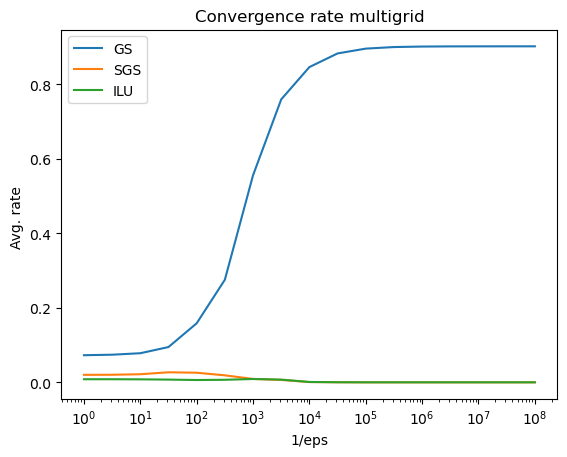

In [24]:

import matplotlib.pyplot as plt
plt.plot(eps, rates_gs, label="GS")
plt.plot(eps, rates_sgs, label="SGS")
plt.plot(eps, rates_ilu, label="ILU")

plt.title("Convergence rate multigrid")
plt.xscale("log")
plt.xlabel("1/eps")

plt.ylabel("Avg. rate ")
plt.legend()